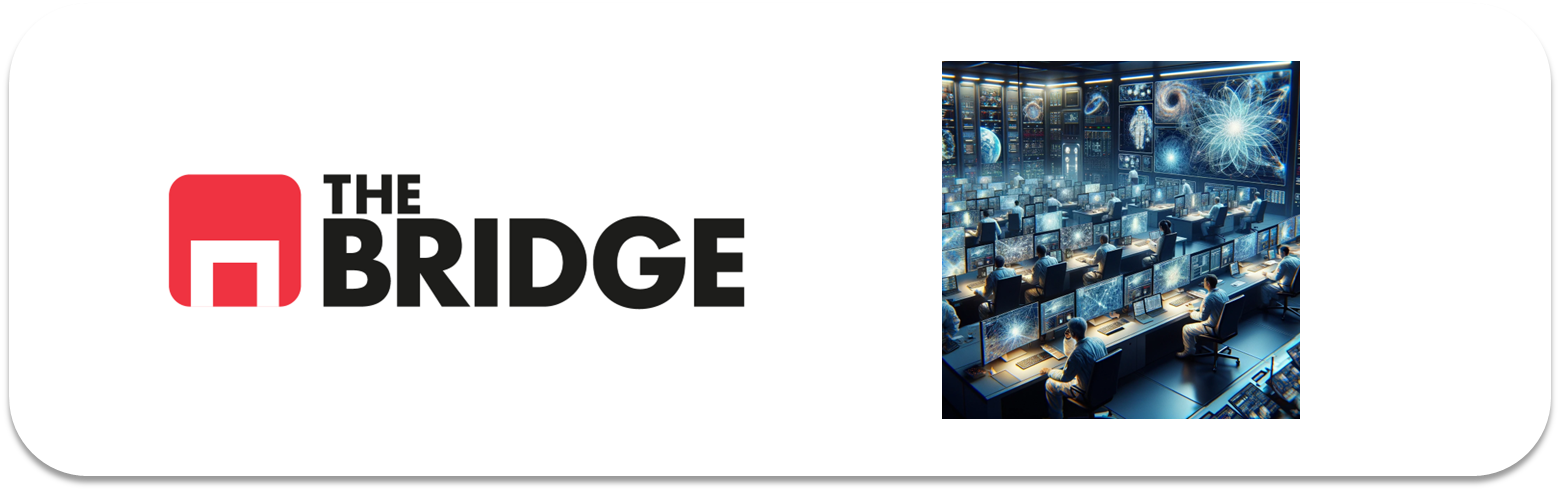

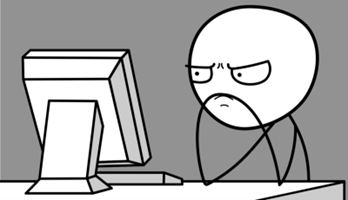

Para ejercitarte y afianzar lo aprendido sobre **Transfer Learning y Fine-tuning**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf



from skimage.io import imread
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tensorflow.keras import datasets, layers, models

## Apple 360

En este conjunto de ejercicios vas a montar un clasificador de manzanas mediante un dataset de imágenes. El dataset se compone de 13 tipos diferentes con aproximadamente unas 200 imágenes por cada tipo. Tendrás que montar un modelo de deep learning que utilice **transfer learning**. Se sugiere empezar con una red ResNet50 con imagenet.

El dataset original proviene del [concurso de Kaggle Fruits 360](https://www.kaggle.com/moltean/fruits), pero adaptado para la clasificación de una menor cantidad de casos (sólo las manzanas).


### Ejercicio 1

Crea los juegos de X,y para train y test a partir de los datos teninendo en cuenta su distribución, para ello tendrás que explorar las estructura. Crea un juego Train,test para resolución 32x32 y un juego de test adicional para 224x224. Es decir tendras que tener un X_train, X_test para 32x32 y un X_test adicional a 224x224

In [2]:
import os

train_path = "./data/apples/Train"
test_path = "./data/apples/Test"

os.listdir(train_path)

['Braeburn',
 'CrimsonSnow',
 'Golden1',
 'Golden2',
 'Golden3',
 'GrannySmith',
 'PinkLady',
 'Red1',
 'Red2',
 'Red3',
 'RedDelicious',
 'RedYellow1',
 'RedYellow2']

In [8]:
def load_dataset(path, size):

    X = []
    y = []

    for label in os.listdir(path):

        folder = os.path.join(path, label)

        for img_name in os.listdir(folder):

            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)
            img = cv2.resize(img, (size, size))

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)

In [9]:
X_train, y_train = load_dataset(train_path, 32)

In [10]:
X_test, y_test = load_dataset(test_path, 32)

In [11]:
X_test_224, y_test_224 = load_dataset(test_path, 224)

In [12]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_test_224:", X_test_224.shape)

X_train: (6404, 32, 32, 3)
X_test: (2134, 32, 32, 3)
X_test_224: (2134, 224, 224, 3)


**NOTA:** A partir de aquí emplea siempre el X_train, X_test de 32x32 salvo en el ejercicio que se te diga lo contrario.

### Ejercicio 2

Haz una visualización de algunos de los datos. Crea una función que te ayude con ello.

In [15]:
import random

def show_random_images(X, y, n=9):

    plt.figure(figsize=(8,8))

    indices = random.sample(range(len(X)), n)

    for i, idx in enumerate(indices):

        plt.subplot(3,3,i+1)
        plt.imshow(X[idx])
        plt.title(y[idx])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

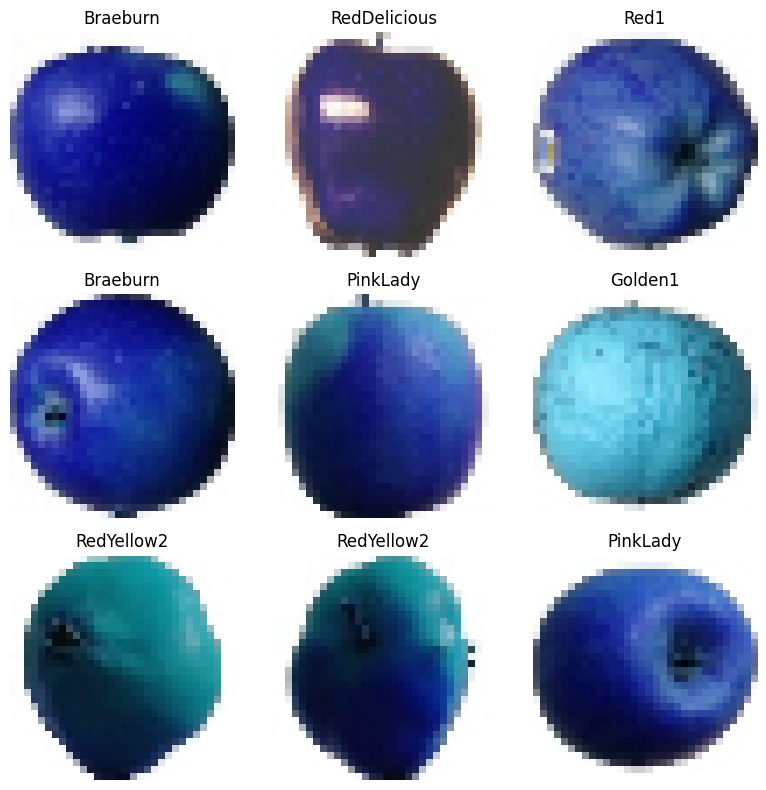

In [17]:
show_random_images(X_train, y_train)

### Ejercicio 3

Completa el miniEDA habitual con imágenes y escoge una métrica para el modelo.

In [18]:
print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 6404
Test samples: 2134


In [19]:
classes = np.unique(y_train)

print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 13
Classes: ['Braeburn' 'CrimsonSnow' 'Golden1' 'Golden2' 'Golden3' 'GrannySmith'
 'PinkLady' 'Red1' 'Red2' 'Red3' 'RedDelicious' 'RedYellow1' 'RedYellow2']


In [25]:
pd.DataFrame(y_train).value_counts()

0           
RedYellow2      672
Golden2         492
Red2            492
GrannySmith     492
Braeburn        492
RedYellow1      492
Red1            492
RedDelicious    490
Golden3         481
Golden1         480
PinkLady        456
CrimsonSnow     444
Red3            429
Name: count, dtype: int64

In [26]:
from collections import Counter

class_counts = Counter(y_train)
print(class_counts)

Counter({np.str_('RedYellow2'): 672, np.str_('Braeburn'): 492, np.str_('Golden2'): 492, np.str_('GrannySmith'): 492, np.str_('Red1'): 492, np.str_('Red2'): 492, np.str_('RedYellow1'): 492, np.str_('RedDelicious'): 490, np.str_('Golden3'): 481, np.str_('Golden1'): 480, np.str_('PinkLady'): 456, np.str_('CrimsonSnow'): 444, np.str_('Red3'): 429})


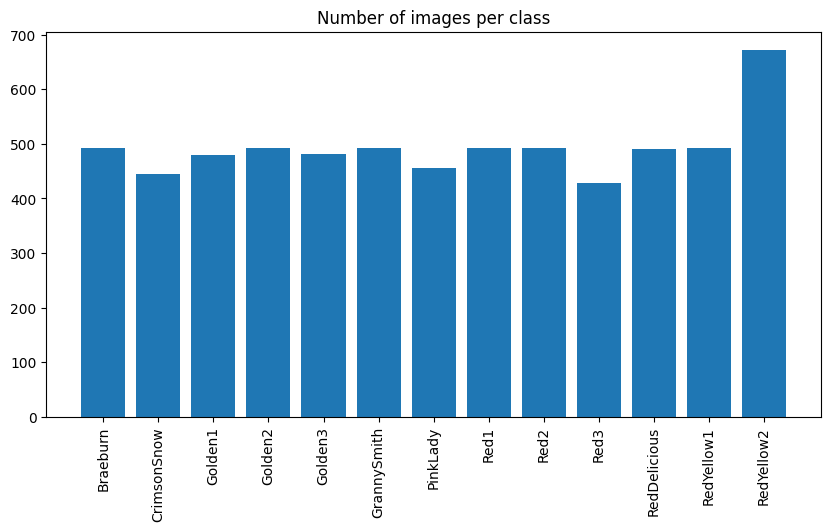

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Number of images per class")
plt.show()

In [ ]:
metrics = ["accuracy"]

### Ejercicio 4 

Termina de transformar los datos si crees que es conveniente y aunque el entrenamiento de modelos de keras ya tiene un shuffling interno, haz un "barajado" del X_train (del X_test no es necesario) para facilitar la convergencia inicial del modelo. Utiliza la función shuffle de sklearn y asigna la salida a un X_train distinto (es decir no machaques el inicial)

In [32]:
from sklearn.utils import shuffle

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train_shuffled, y_train_shuffled = shuffle(X_train, y_train, random_state=42)

In [33]:
print(y_train[:10])
print(y_train_shuffled[:10])

['Braeburn' 'Braeburn' 'Braeburn' 'Braeburn' 'Braeburn' 'Braeburn'
 'Braeburn' 'Braeburn' 'Braeburn' 'Braeburn']
['GrannySmith' 'RedYellow1' 'GrannySmith' 'Golden1' 'RedDelicious'
 'GrannySmith' 'Golden3' 'CrimsonSnow' 'RedDelicious' 'Red3']


### Ejercicio 5

Sklearn permite trabajar con etiquetas textuales pero keras no. Transforma las etiquetas a numéricas, creando dos diccionarios uno que permita traducir de etiqueta a clase numérica y otro que permita la transformación inversa.

In [34]:
labels = np.unique(y_train)
labels

array(['Braeburn', 'CrimsonSnow', 'Golden1', 'Golden2', 'Golden3',
       'GrannySmith', 'PinkLady', 'Red1', 'Red2', 'Red3', 'RedDelicious',
       'RedYellow1', 'RedYellow2'], dtype='<U12')

In [35]:
label_to_class = {label: i for i, label in enumerate(labels)}

In [36]:
class_to_label = {i: label for label, i in label_to_class.items()}

In [41]:
y_train_num = np.array([label_to_class[label] for label in y_train_shuffled])

In [42]:
y_test_num = np.array([label_to_class[label] for label in y_test])

In [44]:
print(y_train_shuffled[:10])
print(y_train_num[:10])

['GrannySmith' 'RedYellow1' 'GrannySmith' 'Golden1' 'RedDelicious'
 'GrannySmith' 'Golden3' 'CrimsonSnow' 'RedDelicious' 'Red3']
[ 5 11  5  2 10  5  4  1 10  9]


### Ejercicio 6: Zero Shot Learning

Descar el modelo ResNet50 preparado ya para poder usarlo directamente a la Zero Shot Learning. Pruébalo contra el test (aquí no valen nuestras categorías serán las que proporcione ResNet ojo). Prueba una selección aleatoria de imágenes del test y compara las etiquetas de ResNet con la que tiene. ¿Nos sirve este clasificador así tal cual?

In [45]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.resnet50 import decode_predictions

In [46]:
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [49]:
indices = np.random.choice(len(X_test_224), 5, replace=False)

In [ ]:
for idx in indices:

    img = X_test_224[idx]
    label = y_test[idx]

    img_input = np.expand_dims(img, axis=0)
    img_input = preprocess_input(img_input)

    preds = model.predict(img_input)

    decoded = decode_predictions(preds, top=1)[0][0][1]

    print("True label:", label)
    print("ResNet prediction:", decoded)
    print()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
True label: RedYellow2
ResNet prediction: punching_bag

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
True label: Braeburn
ResNet prediction: croquet_ball

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
True label: RedDelicious
ResNet prediction: balloon

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
True label: GrannySmith
ResNet prediction: punching_bag

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
True label: PinkLady
ResNet prediction: croquet_ball



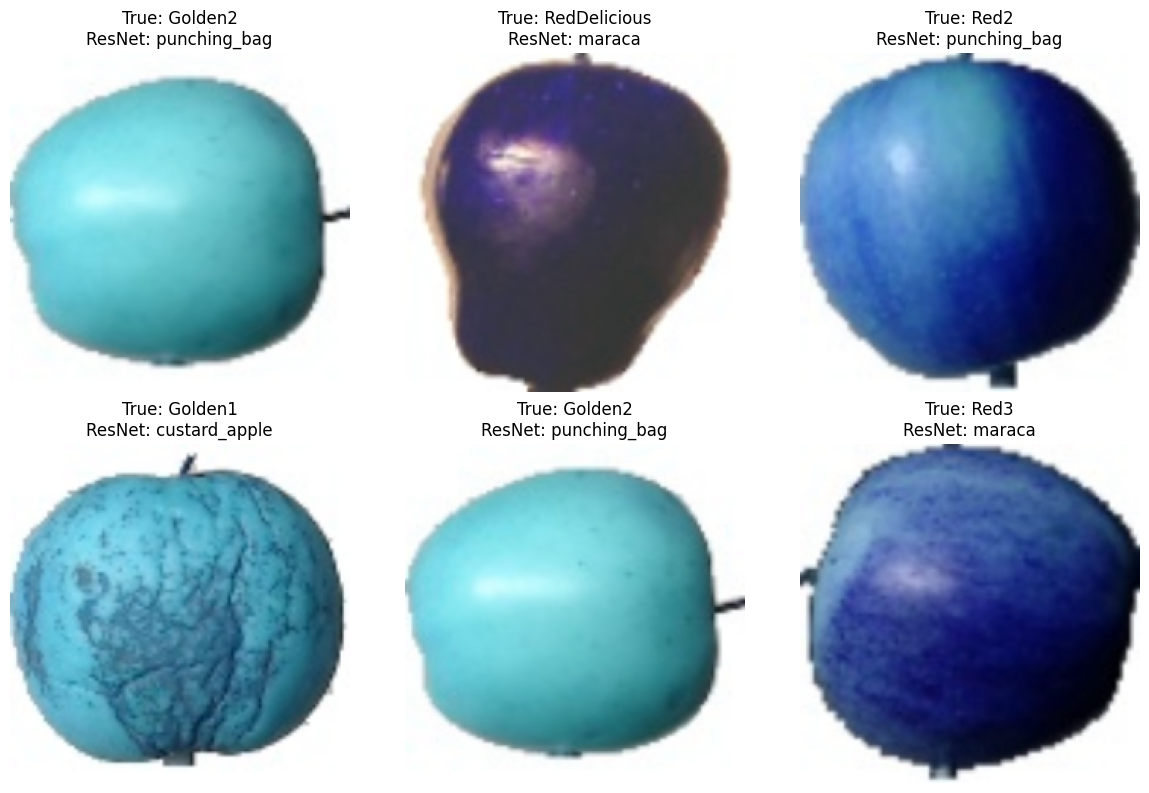

In [54]:
# select random test images
indices = np.random.choice(len(X_test_224), 6, replace=False)

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):

    img = X_test_224[idx]
    true_label = y_test[idx]

    # prepare image for ResNet
    img_input = np.expand_dims(img, axis=0)
    img_input = preprocess_input(img_input)

    # prediction
    preds = model.predict(img_input, verbose=0)
    pred_label = decode_predictions(preds, top=1)[0][0][1]

    # plot
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nResNet: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Transfer Learning

### Ejercicio 7:

Carga la ResNet50 sin cabezas, crea un modelo con el anterior y una cabeza con dos capas densas, una oculta de 300 unidades (con activación "relu") y otra de salida con las unidades que crees necesarias y activación la que consideres. Congela las capas del modelo base (la ResNet50). Define también los hiperparámetros necesarios para compilar y compila el modelo y muestra un summary del mismo.

In [55]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

In [56]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [57]:
for layer in base_model.layers:
    layer.trainable = False

In [58]:
x = base_model.output

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(300, activation='relu')(x)

outputs = layers.Dense(13, activation='softmax')(x)

In [59]:
model = models.Model(inputs=base_model.input, outputs=outputs)

In [60]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,206,325 (92.34 MB)

 Trainable params: 618,613 (2.36 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Ejercicio 8

Entrena el modelo con nuestros datos de train y muestra la evolución del entrenamiento. Emplea un callback de Earlystopping con patience a 5. Termina de escoger el batch_size y el número de épocas.

In [ ]:
X_train_224 = np.array([
    cv2.resize(img, (224, 224)) for img in X_train_shuffled
])

In [72]:
from tensorflow.keras.applications.resnet50 import preprocess_input

X_train_224 = preprocess_input(X_train_224)
X_test_224 = preprocess_input(X_test_224)

In [73]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [74]:
history = model.fit(
    X_train_224,
    y_train_num,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
121/161 ━━━━━━━━━━━━━━━━━━━━ 25s 635ms/step - accuracy: 0.1178 - loss: 5.5874

KeyboardInterrupt: 

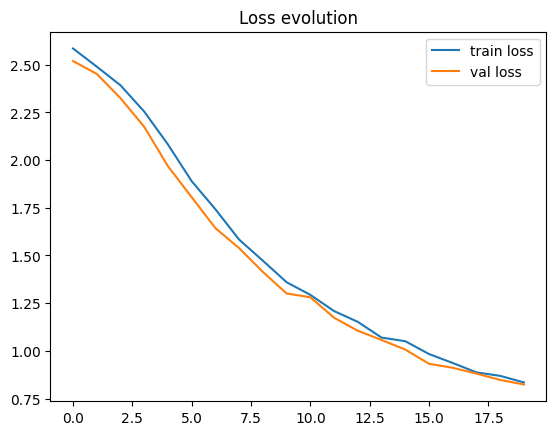

In [68]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss evolution")
plt.show()

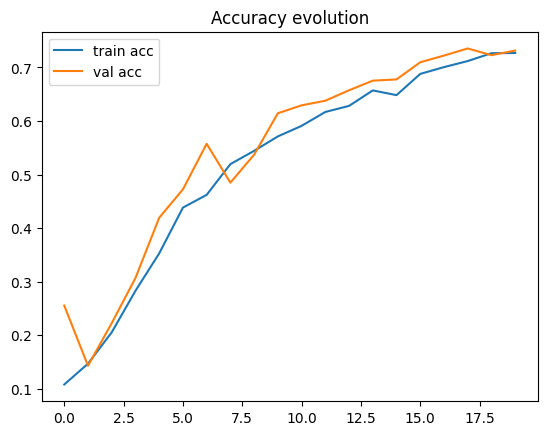

In [69]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy evolution")
plt.show()

### Ejercicio 9

Evalua el modelo contra test y haz un pequeño análisis de las diferencias. Haz un clasification report y muestra la matriz de confusion. Haz un pequeño análisis de errores.

In [70]:
y_pred_probs = model.predict(X_test_224)
y_pred = np.argmax(y_pred_probs, axis=1)

67/67 ━━━━━━━━━━━━━━━━━━━━ 39s 561ms/step


In [71]:
loss, acc = model.evaluate(X_test_224, y_test_num)

print("Test loss:", loss)
print("Test accuracy:", acc)

67/67 ━━━━━━━━━━━━━━━━━━━━ 54s 791ms/step - accuracy: 0.1026 - loss: 140.8408
Test loss: 140.8408203125
Test accuracy: 0.10262417793273926


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_num, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_num, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Fine Tuning

### Ejercicio 10

Vuelve a descargar el modelo ResNet50 pero sin pesos entrenados, ni cabeza, crea el mismo modelo personalizado que en el ejercicio 7, compila y muestra el summary.

### Ejercicio 11
Entrena con batch_size a 64 y 60 épocas, con un EarlyStopping de patience a 10 (ahora el entrenamiento es sensiblemente más largo, así que tómate un descanso). Muestra la evolución y da una posible justificación a emplear tantas épocas de partida.

### Ejercicio 12

Muestra la evaluación contra el test, el informe de clasificación  y la matriz de confusión. Compara los resultados con los del ejercicio 9.